In [1]:
from tqdm import tqdm

import torch
from torch import nn
import torch.nn.functional as F
from torch.optim import Adam, SGD
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Subset

from torchvision.datasets import CIFAR10
from torchvision import transforms

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

# Чтение и подготовка данных

Для начала обозначим преобразования для данных. Нам нужно превратить картинки в тензоры, для этого есть ToTensor(), а также нормализовать данные от 0 до 1 (значения от 0 до 255 имеют большой скейл и нейронки хуже будут с ними работать)

In [2]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

Теперь создадим готовый датасет из PyTorch и загрузчик данных для создания батчей

In [3]:
train_dataset = CIFAR10(root='cifar10', train=True, download=True, transform=transform)

100%|██████████| 170M/170M [00:13<00:00, 12.8MB/s]


In [4]:
print(train_dataset[0][0].shape)

torch.Size([3, 32, 32])


Давайте посмотрим, что возвращает датасет и даталоадер

In [5]:
train_loader = DataLoader(dataset=train_dataset, batch_size=8, shuffle=True)

Посмотрим как выглядит семпл

In [6]:
batch = next(iter(train_loader))
batch[0].shape

torch.Size([8, 3, 32, 32])

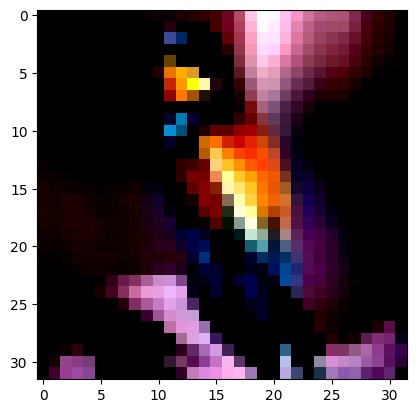

In [7]:
sample_img = batch[0].numpy()[1].transpose(1, 2, 0)

plt.imshow(sample_img)

# Простая CNN

Давайте сделаем простую CNN. Сделаем ее с 3 свертками и пулингом

In [8]:
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(1024, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(-1, 64 * 4 * 4)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

Посмотрим, что она выдаст

In [9]:
cnn = BasicCNN()

out = cnn(batch[0])
print(out.shape)

torch.Size([8, 10])


# Напишем код для тренировки

Тренировка и тестирование будет реализованно в классе Trainer

Обозначим конфиг, где будут параметры для тренировки

In [10]:
config = {
    'num_epochs': 10,
    'lr': 0.01,
    'batch_size': 128,
    'test_size': 0.2
}

In [11]:
class Trainer:
    def __init__(self, config, model_class=BasicCNN, transform=None, model_kwargs=None):
        self.config = config
        self.transform = transform
        self.model_class = model_class
        self.model_kwargs = model_kwargs or {}

        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.model = self.model_class(**self.model_kwargs).to(self.device)

        self.optimizer = Adam(self.model.parameters(), lr=self.config['lr'])
        self.scheduler = StepLR(self.optimizer, step_size=5, gamma=0.1)
        self.loss_function = nn.CrossEntropyLoss()

        self.history = {
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': [],
            'test_loss': None,
            'test_acc': None
        }

        self.best_val_loss = float('inf')
        self.best_state = None

        self.setup_dataloaders()

    def setup_dataloaders(self):
        train_dataset_full = CIFAR10(root='cifar10', train=True, download=True, transform=self.transform)
        test_dataset = CIFAR10(root='cifar10', train=False, download=True, transform=self.transform)

        train_indices, val_indices = train_test_split(
            list(range(len(train_dataset_full))),
            test_size=self.config['test_size'],
            random_state=42,
            shuffle=True,
            stratify=train_dataset_full.targets
        )

        train_dataset = Subset(train_dataset_full, train_indices)
        val_dataset = Subset(train_dataset_full, val_indices)

        pin_memory = torch.cuda.is_available()

        self.train_loader = DataLoader(train_dataset, batch_size=self.config['batch_size'], shuffle=True, pin_memory=pin_memory)
        self.val_loader = DataLoader(val_dataset, batch_size=self.config['batch_size'], shuffle=False, pin_memory=pin_memory)
        self.test_loader = DataLoader(test_dataset, batch_size=self.config['batch_size'], shuffle=False, pin_memory=pin_memory)

    def _run_epoch(self, loader, train=False, desc=None):
        if train:
            self.model.train()
        else:
            self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(loader, desc=desc):
            images = images.to(self.device)
            labels = labels.to(self.device)

            if train:
                self.optimizer.zero_grad()

            with torch.set_grad_enabled(train):
                outputs = self.model(images)
                loss = self.loss_function(outputs, labels)

                if train:
                    loss.backward()
                    self.optimizer.step()

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += batch_size

        avg_loss = total_loss / total_samples
        avg_acc = correct / total_samples * 100

        return avg_loss, avg_acc

    def train_step(self):
        train_loss, train_acc = self._run_epoch(self.train_loader, train=True, desc='train')
        self.scheduler.step()
        return train_loss, train_acc

    def val_step(self):
        return self._run_epoch(self.val_loader, train=False, desc='val')

    def test_step(self):
        return self._run_epoch(self.test_loader, train=False, desc='test')

    def run(self):
        for epoch in range(self.config['num_epochs']):
            train_loss, train_acc = self.train_step()
            val_loss, val_acc = self.val_step()

            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)

            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.best_state = {k: v.detach().cpu().clone() for k, v in self.model.state_dict().items()}

            print(
                f"Epoch {epoch + 1}/{self.config['num_epochs']} | "
                f"train_loss={train_loss:.4f} train_acc={train_acc:.2f}% | "
                f"val_loss={val_loss:.4f} val_acc={val_acc:.2f}%"
            )

        self.model.load_state_dict(self.best_state)
        test_loss, test_acc = self.test_step()
        self.history['test_loss'] = test_loss
        self.history['test_acc'] = test_acc

        print(f"Best val_loss={self.best_val_loss:.4f}")
        print(f"Test loss={test_loss:.4f} | Test acc={test_acc:.2f}%")

        return self.history

In [12]:
trainer = Trainer(config, transform=transform)

In [13]:
trainer.run()

val: 100%|██████████| 79/79 [00:02<00:00, 29.11it/s]


Epoch 1/10 | train_loss=1.8014 train_acc=33.15% | val_loss=1.5433 val_acc=43.26%


val: 100%|██████████| 79/79 [00:03<00:00, 20.15it/s]


Epoch 2/10 | train_loss=1.4976 train_acc=45.12% | val_loss=1.4642 val_acc=47.22%


val: 100%|██████████| 79/79 [00:03<00:00, 25.23it/s]


...

val: 100%|██████████| 79/79 [00:02<00:00, 28.77it/s]


Epoch 10/10 | train_loss=1.0556 train_acc=62.20% | val_loss=1.1853 val_acc=58.23%


test: 100%|██████████| 79/79 [00:03<00:00, 23.24it/s]

Best val_loss=1.1853
Test loss=1.1650 | Test acc=58.59%


{'train_loss': [1.8014252426147461,
  1.497624661254883,
  1.4130685901641846,
  1.3617264671325684,
  1.307651670074463,
  1.1496989078521729,
  1.1067514019012452,
  1.0860383333206176,
  1.0684808473587035,
  1.055574394416809],
 'train_acc': [33.15,
  45.1175,
  48.975,
  50.932500000000005,
  52.885000000000005,
  58.8125,
  60.3775,
  61.12,
  61.67,
  62.195],
 'val_loss': [1.543260129547119,
  1.4642338970184325,
  1.386693549346924,
  1.3522094556808473,
  1.3243224594116212,
  1.220276633834839,
  1.2107376781463624,
  1.2004763866424562,
  1.1958307498931884,
  1.1853493591308595],
 'val_acc': [43.26,
  47.22,
  50.080000000000005,
  50.86000000000001,
  53.49,
  57.05,
  57.269999999999996,
  57.769999999999996,
  57.720000000000006,
  58.230000000000004],
 'test_loss': 1.1649763271331788,
 'test_acc': 58.589999999999996}

# ResNet-18

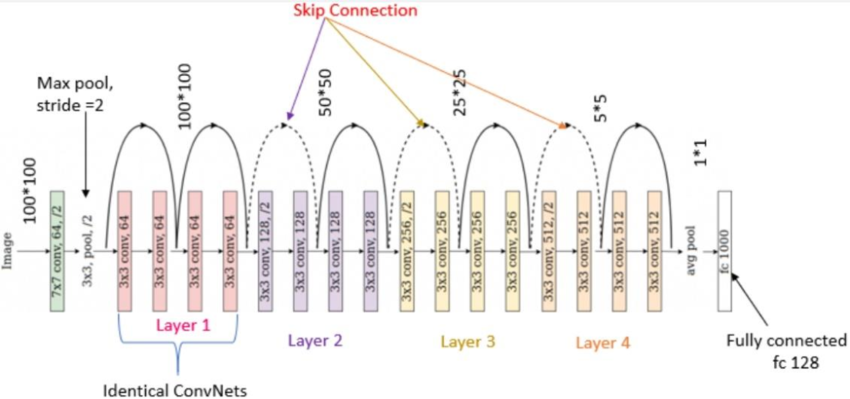

In [14]:
class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out, inplace=True)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out = out + identity
        out = F.relu(out, inplace=True)

        return out


class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        self.layer1 = self.make_layer(64, blocks=2, stride=1)
        self.layer2 = self.make_layer(128, blocks=2, stride=2)
        self.layer3 = self.make_layer(256, blocks=2, stride=2)
        self.layer4 = self.make_layer(512, blocks=2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def make_layer(self, out_channels, blocks, stride=1):
        downsample = None

        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        layers = [ResNetBlock(self.in_channels, out_channels, stride=stride, downsample=downsample)]
        self.in_channels = out_channels

        for _ in range(1, blocks):
            layers.append(ResNetBlock(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x, inplace=True)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

$H_{out}=\frac{H_{in}+2P-D(K-1)-1}{S}+1$ \\
$W_{out}=\frac{W_{in}+2P-D(K-1)-1}{S}+1$

val: 100%|██████████| 79/79 [00:04<00:00, 16.56it/s]


Epoch 1/10 | train_loss=1.7662 train_acc=36.18% | val_loss=1.5766 val_acc=41.15%


val: 100%|██████████| 79/79 [00:04<00:00, 17.30it/s]


Epoch 2/10 | train_loss=1.2892 train_acc=53.04% | val_loss=1.1515 val_acc=58.43%


val: 100%|██████████| 79/79 [00:04<00:00, 17.16it/s]


...

Epoch 9/10 | train_loss=0.1671 train_acc=94.48% | val_loss=0.7654 val_acc=79.12%


val: 100%|██████████| 79/79 [00:04<00:00, 17.57it/s]


Epoch 10/10 | train_loss=0.0902 train_acc=97.25% | val_loss=0.8905 val_acc=78.73%


test: 100%|██████████| 79/79 [00:04<00:00, 17.52it/s]


Best val_loss=0.6231
Test loss=0.6366 | Test acc=78.64%


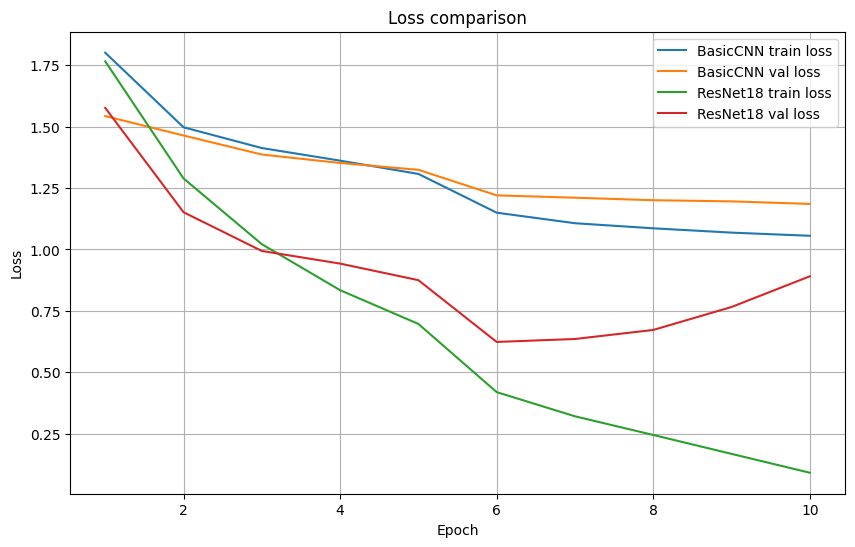

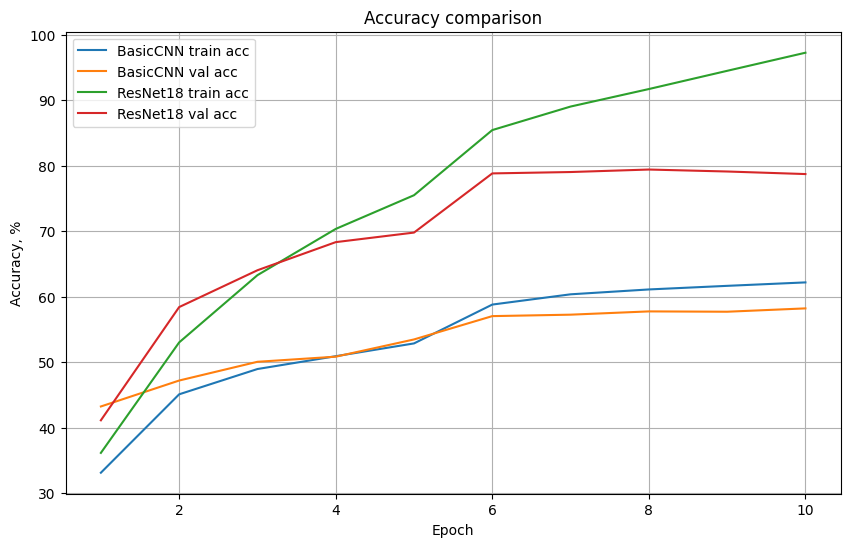

BasicCNN test loss: 1.1650
BasicCNN test acc: 58.59%
ResNet18 test loss: 0.6366
ResNet18 test acc: 78.64%


In [15]:
basic_history = trainer.history

resnet_trainer = Trainer(config, model_class=ResNet18, transform=transform)
resnet_history = resnet_trainer.run()

epochs = range(1, config['num_epochs'] + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, basic_history['train_loss'], label='BasicCNN train loss')
plt.plot(epochs, basic_history['val_loss'], label='BasicCNN val loss')
plt.plot(epochs, resnet_history['train_loss'], label='ResNet18 train loss')
plt.plot(epochs, resnet_history['val_loss'], label='ResNet18 val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss comparison')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(epochs, basic_history['train_acc'], label='BasicCNN train acc')
plt.plot(epochs, basic_history['val_acc'], label='BasicCNN val acc')
plt.plot(epochs, resnet_history['train_acc'], label='ResNet18 train acc')
plt.plot(epochs, resnet_history['val_acc'], label='ResNet18 val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy, %')
plt.title('Accuracy comparison')
plt.legend()
plt.grid(True)
plt.show()

print(f"BasicCNN test loss: {basic_history['test_loss']:.4f}")
print(f"BasicCNN test acc: {basic_history['test_acc']:.2f}%")
print(f"ResNet18 test loss: {resnet_history['test_loss']:.4f}")
print(f"ResNet18 test acc: {resnet_history['test_acc']:.2f}%")

ResNet18 показала более высокое качество по сравнению с простой CNN.
По графикам видно, что loss у ResNet18 снижается лучше, а accuracy выше на train/val.

Итоговая test accuracy у ResNet18 также выше, поэтому она является более эффективной архитектурой для CIFAR-10.